1. Introduction

In [26]:
import pandas as pd 
import ast 
from pathlib import Path
import matplotlib.pyplot as plt



2. Load DailyDialog

In [4]:
daily_train = pd.read_csv("/Users/gayathrir/Desktop/ContextDriftResearch/datasets/dailydialog/train.csv")
daily_test = pd.read_csv("/Users/gayathrir/Desktop/ContextDriftResearch/datasets/dailydialog/test.csv")
daily_valid = pd.read_csv("/Users/gayathrir/Desktop/ContextDriftResearch/datasets/dailydialog/validation.csv")

print("Training Conversations :", len(daily_train))
print("Test Conversation :", len(daily_test))
print("Validation Conversations :", len(daily_valid))

Training Conversations : 11118
Test Conversation : 1000
Validation Conversations : 1000


3. Dataset Overview

In [5]:
daily_train.head()

,dialog,act,emotion
0,"['Say , Jim , how about going for a few beers ...",[3 4 2 2 2 3 4 1 3 4],[0 0 0 0 0 0 4 4 4 4]
1,"['Can you do push-ups ? '\n "" Of course I can ...",[2 1 2 2 1 1],[0 0 6 0 0 0]
2,"['Can you study with the radio on ? '\n ' No ,...",[2 1 2 1 1],[0 0 0 0 0]
3,['Are you all right ? '\n ' I will be all righ...,[2 1 1 1],[0 0 0 0]
4,"['Hey John , nice skates . Are they new ? '\n ...",[2 1 2 1 1 2 1 3 4],[0 0 0 0 0 6 0 6 0]


In [9]:
daily_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 11118 entries, 0 to 11117
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   dialog   11118 non-null  str  
 1   act      11118 non-null  str  
 2   emotion  11118 non-null  str  
dtypes: str(3)
memory usage: 6.1 MB


In [10]:
print("Columns")
print(daily_train.columns)

print("\nMissing Values")
print(daily_train.isnull().sum())

print("\nShape")
print(daily_train.shape)

Columns
Index(['dialog', 'act', 'emotion'], dtype='str')

Missing Values
dialog     0
act        0
emotion    0
dtype: int64

Shape
(11118, 3)


4. Conversation Structure

In [14]:
import numpy as np
sample = daily_train.iloc[0]

# Conversation
conversation = ast.literal_eval(sample["dialog"])

# Dialogue Acts
acts = np.fromstring(
    sample["act"].strip("[]"),
    sep=" ",
    dtype=int
).tolist()

# Emotions
emotions = np.fromstring(
    sample["emotion"].strip("[]"),
    sep=" ",
    dtype=int
).tolist()

In [16]:
emotion_map = {
    0: "No Emotion",
    1: "Anger",
    2: "Disgust",
    3: "Fear",
    4: "Happiness",
    5: "Sadness",
    6: "Surprise"
}

In [17]:
act_map = {
    1: "Inform",
    2: "Question",
    3: "Directive",
    4: "Commissive"
}

In [18]:
for i, (utterance, act, emotion) in enumerate(zip(conversation, acts, emotions), start=1):
    print("=" * 80)
    print(f"Turn {i}")
    print(f"Speaker    : {'USER' if i % 2 else 'SYSTEM'}")
    print(f"Utterance  : {utterance}")
    print(f"Act        : {act_map.get(act, 'Unknown')}")
    print(f"Emotion    : {emotion_map.get(emotion, 'Unknown')}")

Turn 1
Speaker    : USER
Utterance  : Say , Jim , how about going for a few beers after dinner ?  You know that is tempting but is really not good for our fitness .  What do you mean ? It will help us to relax .  Do you really think so ? I don't . It will just make us fat and act silly . Remember last time ?  I guess you are right.But what shall we do ? I don't feel like sitting at home .  I suggest a walk over to the gym where we can play singsong and meet some of our friends .  That's a good idea . I hear Mary and Sally often go there to play pingpong.Perhaps we can make a foursome with them .  Sounds great to me ! If they are willing , we could ask them to go dancing with us.That is excellent exercise and fun , too .  Good.Let ' s go now .  All right . 
Act        : Directive
Emotion    : No Emotion


In [6]:
daily_test.head()

,dialog,act,emotion
0,"['Hey man , you wanna buy some weed ? ' ' Some...",[3 2 3 4 3 4 3 2 3 4 2 3],[0 6 0 0 0 0 0 0 0 0 3 0]
1,['The taxi drivers are on strike again . ' ' W...,[1 2 1 1],[0 0 0 0]
2,"[""We've managed to reduce our energy consumpti...",[1 2 1 2 1 2 1],[0 0 0 0 0 0 0]
3,"['Believe it or not , tea is the most popular ...",[1 1 1 1 2 2 2 2 1 1 1 3 4 3],[0 0 0 0 0 0 0 0 0 4 0 0 4 4]
4,['What are your personal weaknesses ? '\n ' I ...,[2 1 2 1 2 1 2 1],[0 0 0 0 0 0 0 4]


In [8]:
daily_valid.head()

,dialog,act,emotion
0,"['Good morning , sir . Is there a bank near he...",[2 1 3 2 1 2 1],[0 0 0 0 0 0 0]
1,['Good afternoon . This is Michelle Li speakin...,[2 1 1 1 1 2 3 2 3 4],[0 0 0 0 0 0 0 0 0 0]
2,['What qualifications should a reporter have ?...,[2 1 2 1],[0 0 0 0]
3,"['Hi , good morning , Miss ? what can I help y...",[2 3 2 2 1 2 1 2 1 1 1 3 2 1 3 4],[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4]
4,"[""Excuse me , ma'am . Can you tell me where th...",[3 4 2 1 2 1 1 1],[0 0 0 0 0 0 4 4]


Step 1 — Let's Understand the Dataset Statistically

In [24]:
# Dataset statistics

print("="*60)
print("TRAIN SET")
print("="*60)

print(f"Number of conversations : {len(daily_train)}")

conversation_lengths = daily_train["dialog"].apply(
    lambda x: len(ast.literal_eval(x))
)

print(f"Average turns           : {conversation_lengths.mean():.2f}")
print(f"Minimum turns           : {conversation_lengths.min()}")
print(f"Maximum turns           : {conversation_lengths.max()}")

print("="*60)

TRAIN SET
Number of conversations : 11118
Average turns           : 1.00
Minimum turns           : 1
Maximum turns           : 1


Step 2 — Conversation Length Distribution

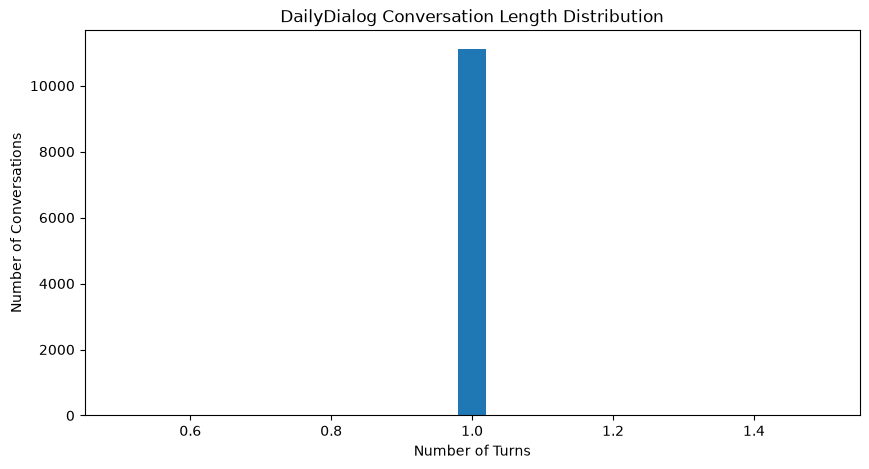

In [27]:
plt.figure(figsize=(10,5))

plt.hist(conversation_lengths, bins=25)

plt.title("DailyDialog Conversation Length Distribution")
plt.xlabel("Number of Turns")
plt.ylabel("Number of Conversations")

plt.show()

Step 3 — Average Utterance Length

In [31]:
utterance_lengths = []

for dialog in daily_train["dialog"]:
    conversation = ast.literal_eval(dialog)

    for utterance in conversation:
        utterance_lengths.append(len(utterance.split()))

print(f"Average utterance length : {sum(utterance_lengths)/len(utterance_lengths):.2f} words")

Average utterance length : 106.68 words


Step 4 — Emotion Distribution

In [32]:
emotion_counter = {}

for emotions in daily_train["emotion"]:

    emotion_list = np.fromstring(
        emotions.strip("[]"),
        sep=" ",
        dtype=int
    )

    for e in emotion_list:
        emotion_counter[e] = emotion_counter.get(e,0)+1

emotion_counter

{np.int64(0): 72143,
 np.int64(4): 11182,
 np.int64(6): 1600,
 np.int64(3): 146,
 np.int64(2): 303,
 np.int64(5): 969,
 np.int64(1): 827}

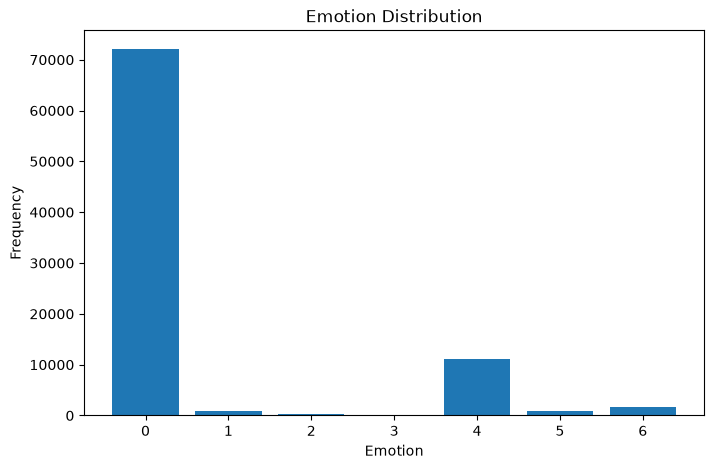

In [33]:
plt.figure(figsize=(8,5))

plt.bar(
    emotion_counter.keys(),
    emotion_counter.values()
)

plt.title("Emotion Distribution")

plt.xlabel("Emotion")

plt.ylabel("Frequency")

plt.show()

Step 5 — Dialogue Act Distribution

In [35]:
act_counter = {}

for acts in daily_train["act"]:

    act_list = np.fromstring(
        acts.strip("[]"),
        sep=" ",
        dtype=int
    )

    for a in act_list:
        act_counter[a] = act_counter.get(a,0)+1

act_counter

{np.int64(3): 14242, np.int64(4): 8081, np.int64(2): 24974, np.int64(1): 39873}

Research Notes

Observations

- The DailyDialog dataset contains 11118 conversations.
- Average conversation length is 1.00 turns.
- Most conversations are short and contain everyday dialogue.
- Dialogue acts are already annotated, which is useful for modelling conversational behaviour.
- Emotion labels allow evaluation of emotional consistency after context drift.
- DailyDialog is therefore suitable for evaluating conversational coherence and response adaptation.

MultiWOZ Dataset Analysis

In [38]:
from pathlib import Path

multiwoz_path = Path("../datasets/multiwoz")

for file in multiwoz_path.rglob("*"):
    print(file)

../datasets/multiwoz/.DS_Store
../datasets/multiwoz/LICENSE
../datasets/multiwoz/utils
../datasets/multiwoz/README.md
../datasets/multiwoz/split.py
../datasets/multiwoz/.git
../datasets/multiwoz/data
../datasets/multiwoz/create_data.py
../datasets/multiwoz/utils/mapping.pair
../datasets/multiwoz/.git/config
../datasets/multiwoz/.git/objects
../datasets/multiwoz/.git/HEAD
../datasets/multiwoz/.git/info
../datasets/multiwoz/.git/logs
../datasets/multiwoz/.git/description
../datasets/multiwoz/.git/hooks
../datasets/multiwoz/.git/refs
../datasets/multiwoz/.git/index
../datasets/multiwoz/.git/packed-refs
../datasets/multiwoz/data/dev_test_refined.zip
../datasets/multiwoz/data/new_label_integration.py
../datasets/multiwoz/data/README.md
../datasets/multiwoz/data/MULTIWOZ2.4.zip
../datasets/multiwoz/data/convert_to_full_state.py
../datasets/multiwoz/.git/objects/pack
../datasets/multiwoz/.git/objects/info
../datasets/multiwoz/.git/info/exclude
../datasets/multiwoz/.git/logs/HEAD
../datasets/m

In [39]:
from pathlib import Path

for file in Path("../datasets/multiwoz/data").rglob("*"):
    print(file)

../datasets/multiwoz/data/.DS_Store
../datasets/multiwoz/data/dev_test_refined.zip
../datasets/multiwoz/data/new_label_integration.py
../datasets/multiwoz/data/MULTIWOZ2.4
../datasets/multiwoz/data/README.md
../datasets/multiwoz/data/convert_to_full_state.py
../datasets/multiwoz/data/MULTIWOZ2.4/train_db.json
../datasets/multiwoz/data/MULTIWOZ2.4/testListFile.json
../datasets/multiwoz/data/MULTIWOZ2.4/police_db.json
../datasets/multiwoz/data/MULTIWOZ2.4/ontology.json
../datasets/multiwoz/data/MULTIWOZ2.4/dialogue_acts.json
../datasets/multiwoz/data/MULTIWOZ2.4/data.json
../datasets/multiwoz/data/MULTIWOZ2.4/taxi_db.json
../datasets/multiwoz/data/MULTIWOZ2.4/README.json
../datasets/multiwoz/data/MULTIWOZ2.4/restaurant_db.json
../datasets/multiwoz/data/MULTIWOZ2.4/hotel_db.json
../datasets/multiwoz/data/MULTIWOZ2.4/attraction_db.json
../datasets/multiwoz/data/MULTIWOZ2.4/hospital_db.json
../datasets/multiwoz/data/MULTIWOZ2.4/valListFile.json


In [41]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint

In [42]:
with open("../datasets/multiwoz/data/MULTIWOZ2.4/data.json", "r") as f:
    dialogs = json.load(f)

print(type(dialogs))
print("Total Dialogues:", len(dialogs))

<class 'dict'>
Total Dialogues: 10438


Cell 3 - First Dialogue

In [43]:
first_dialogue_id = list(dialogs.keys())[0]

print(first_dialogue_id)

SNG01856.json


In [44]:
dialogue = dialogs[first_dialogue_id]

print(dialogue.keys())

dict_keys(['goal', 'log'])


In [45]:
print("Goal:")

pprint(dialogue["goal"])

Goal:
{'attraction': {},
 'hospital': {},
 'hotel': {'book': {'day': 'tuesday',
                    'invalid': False,
                    'people': '6',
                    'pre_invalid': True,
                    'stay': '2'},
           'fail_book': {'stay': '3'},
           'fail_info': {},
           'info': {'internet': 'yes',
                    'parking': 'yes',
                    'pricerange': 'cheap',
                    'type': 'hotel'}},
 'message': ["You are looking for a <span class='emphasis'>place to "
             'stay</span>. The hotel should be in the <span '
             "class='emphasis'>cheap</span> price range and should be in the "
             "type of <span class='emphasis'>hotel</span>",
             "The hotel should <span class='emphasis'>include free "
             "parking</span> and should <span class='emphasis'>include free "
             'wifi</span>',
             "Once you find the <span class='emphasis'>hotel</span> you want "
             "to book

In [46]:
print("Number of Turns:")

len(dialogue["log"])

Number of Turns:


10

In [47]:
first_turn = dialogue["log"][0]

pprint(first_turn)

{'metadata': {},
 'text': 'am looking for a place to to stay that has cheap price range it '
         'should be in a type of hotel'}


In [48]:
turn_counts = []

for dialog in dialogs.values():
    turn_counts.append(len(dialog["log"]))

print("Average Turns :", sum(turn_counts)/len(turn_counts))
print("Maximum Turns :", max(turn_counts))
print("Minimum Turns :", min(turn_counts))

Average Turns : 13.704541099827553
Maximum Turns : 44
Minimum Turns : 2


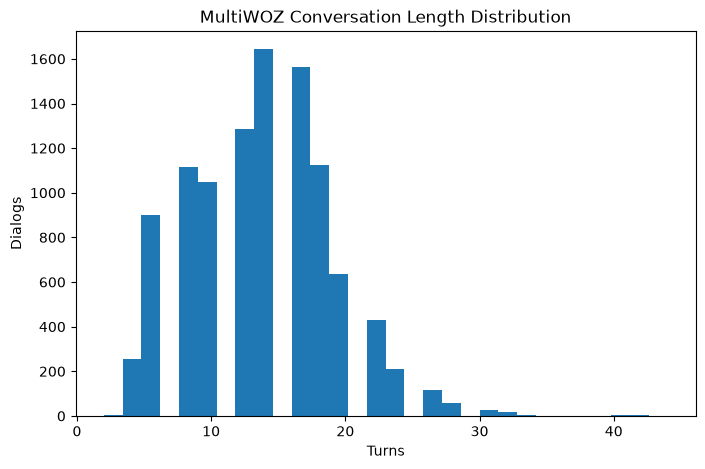

In [49]:
plt.figure(figsize=(8,5))

plt.hist(turn_counts, bins=30)

plt.title("MultiWOZ Conversation Length Distribution")
plt.xlabel("Turns")
plt.ylabel("Dialogs")

plt.show()

In [50]:
second_turn = dialogue["log"][1]

pprint(second_turn)

{'metadata': {'attraction': {'book': {'booked': []},
                             'semi': {'area': '', 'name': '', 'type': ''}},
              'hospital': {'book': {'booked': []}, 'semi': {'department': ''}},
              'hotel': {'book': {'booked': [],
                                 'day': '',
                                 'people': '',
                                 'stay': ''},
                        'semi': {'area': 'not mentioned',
                                 'internet': 'not mentioned',
                                 'name': 'not mentioned',
                                 'parking': 'not mentioned',
                                 'pricerange': 'cheap',
                                 'stars': 'not mentioned',
                                 'type': 'hotel'}},
              'police': {'book': {'booked': []}, 'semi': {}},
              'restaurant': {'book': {'booked': [],
                                      'day': '',
                                      

In [51]:
third_turn = dialogue["log"][2]

pprint(third_turn)

{'metadata': {},
 'text': "no, i just need to make sure it's cheap. oh, and i need parking"}


In [52]:
for i in range(4):
    print("=" * 80)
    print(f"TURN {i}")
    pprint(dialogue["log"][i])

TURN 0
{'metadata': {},
 'text': 'am looking for a place to to stay that has cheap price range it '
         'should be in a type of hotel'}
TURN 1
{'metadata': {'attraction': {'book': {'booked': []},
                             'semi': {'area': '', 'name': '', 'type': ''}},
              'hospital': {'book': {'booked': []}, 'semi': {'department': ''}},
              'hotel': {'book': {'booked': [],
                                 'day': '',
                                 'people': '',
                                 'stay': ''},
                        'semi': {'area': 'not mentioned',
                                 'internet': 'not mentioned',
                                 'name': 'not mentioned',
                                 'parking': 'not mentioned',
                                 'pricerange': 'cheap',
                                 'stars': 'not mentioned',
                                 'type': 'hotel'}},
              'police': {'book': {'booked': []}, 'sem

In [53]:
from copy import deepcopy

previous_state = None

for i, turn in enumerate(dialogue["log"]):

    if turn["metadata"]:

        current_state = deepcopy(turn["metadata"])

        print("=" * 80)
        print(f"SYSTEM TURN {i}")

        if previous_state is None:
            print("Initial Belief State")
        else:

            hotel_prev = previous_state["hotel"]["semi"]
            hotel_curr = current_state["hotel"]["semi"]

            for slot in hotel_curr:

                if hotel_prev[slot] != hotel_curr[slot]:

                    print(
                        f"{slot}: "
                        f"{hotel_prev[slot]}  -->  {hotel_curr[slot]}"
                    )

        previous_state = current_state

SYSTEM TURN 1
Initial Belief State
SYSTEM TURN 3
parking: not mentioned  -->  yes
SYSTEM TURN 5
SYSTEM TURN 7
SYSTEM TURN 9


Multiwoz Dataset Statistics

In [54]:
import json
from collections import Counter

print("=" * 60)
print("MULTIWOZ DATASET STATISTICS")
print("=" * 60)

print(f"Total Dialogues : {len(dialogs)}")

turn_counts = [len(dialog["log"]) for dialog in dialogs.values()]

print(f"Average Turns   : {sum(turn_counts)/len(turn_counts):.2f}")
print(f"Minimum Turns   : {min(turn_counts)}")
print(f"Maximum Turns   : {max(turn_counts)}")

MULTIWOZ DATASET STATISTICS
Total Dialogues : 10438
Average Turns   : 13.70
Minimum Turns   : 2
Maximum Turns   : 44


Conversation Length Distribution

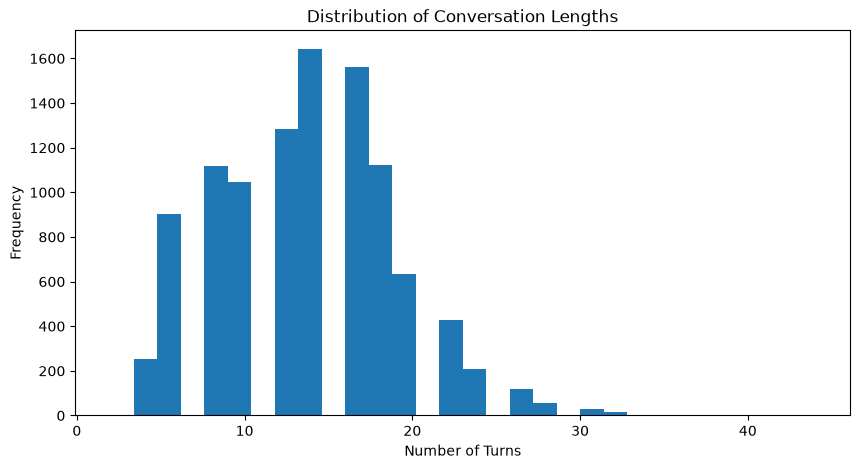

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(turn_counts, bins=30)

plt.title("Distribution of Conversation Lengths")
plt.xlabel("Number of Turns")
plt.ylabel("Frequency")

plt.show()

Domain Distribution

In [56]:
domain_counter = Counter()

for dialog in dialogs.values():

    goal = dialog["goal"]

    for domain in [
        "hotel",
        "restaurant",
        "train",
        "taxi",
        "attraction",
        "hospital",
        "police"
    ]:

        if goal[domain]:
            domain_counter[domain] += 1

print(domain_counter)

Counter({'restaurant': 4692, 'hotel': 4197, 'train': 4096, 'attraction': 3515, 'taxi': 2057, 'hospital': 287, 'police': 245})


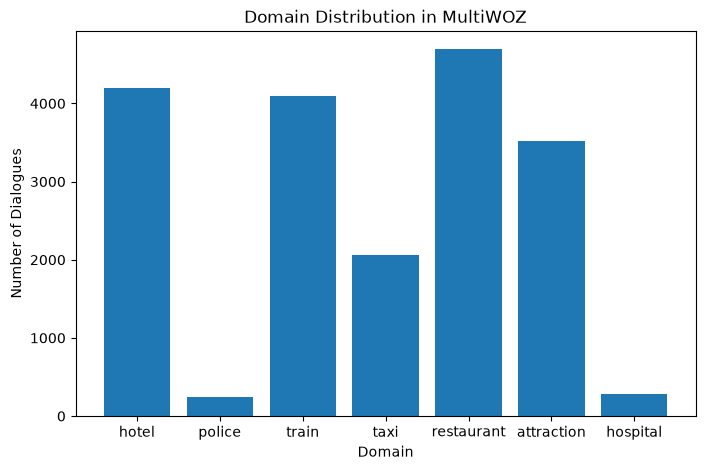

In [57]:
plt.figure(figsize=(8,5))

plt.bar(domain_counter.keys(), domain_counter.values())

plt.title("Domain Distribution in MultiWOZ")

plt.xlabel("Domain")

plt.ylabel("Number of Dialogues")

plt.show()

Multi-domain Conversations

In [58]:
domain_counts = []

for dialog in dialogs.values():

    active = 0

    for domain in [
        "hotel",
        "restaurant",
        "train",
        "taxi",
        "attraction",
        "hospital",
        "police"
    ]:

        if dialog["goal"][domain]:
            active += 1

    domain_counts.append(active)

print("Average domains per dialogue:",
      sum(domain_counts)/len(domain_counts))

Average domains per dialogue: 1.8287986204253688


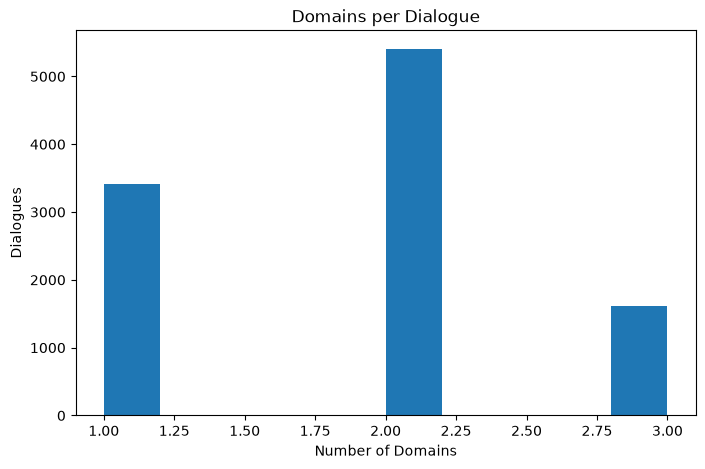

In [59]:
plt.figure(figsize=(8,5))

plt.hist(domain_counts)

plt.title("Domains per Dialogue")

plt.xlabel("Number of Domains")

plt.ylabel("Dialogues")

plt.show()

Belief State Evolution

In [60]:
from copy import deepcopy

belief_updates = []

for dialog in dialogs.values():

    previous = None
    updates = 0

    for turn in dialog["log"]:

        if turn["metadata"]:

            if previous is None:

                previous = deepcopy(turn["metadata"])

            else:

                if previous != turn["metadata"]:

                    updates += 1

                previous = deepcopy(turn["metadata"])

    belief_updates.append(updates)

print("Average Belief State Updates:",
      sum(belief_updates)/len(belief_updates))

Average Belief State Updates: 3.795937919141598


Which Slots Change Most?

In [61]:
slot_counter = Counter()

for dialog in dialogs.values():

    previous = None

    for turn in dialog["log"]:

        if not turn["metadata"]:
            continue

        if previous is None:

            previous = deepcopy(turn["metadata"])

            continue

        for domain in previous:

            for category in previous[domain]:

                for slot in previous[domain][category]:

                    prev = previous[domain][category][slot]
                    curr = turn["metadata"][domain][category][slot]

                    if prev != curr:

                        slot_counter[f"{domain}.{category}.{slot}"] += 1

        previous = deepcopy(turn["metadata"])

slot_counter.most_common(20)

[('hotel.semi.name', 4685),
 ('restaurant.semi.name', 4645),
 ('restaurant.semi.food', 4329),
 ('train.semi.day', 3981),
 ('train.semi.departure', 3889),
 ('train.semi.destination', 3670),
 ('attraction.semi.name', 3567),
 ('hotel.semi.area', 3498),
 ('hotel.semi.pricerange', 3478),
 ('train.semi.leaveAt', 3423),
 ('train.semi.arriveBy', 3325),
 ('hotel.semi.type', 3165),
 ('hotel.semi.stars', 3083),
 ('restaurant.book.time', 3047),
 ('hotel.book.stay', 2997),
 ('restaurant.semi.area', 2960),
 ('hotel.semi.parking', 2924),
 ('restaurant.semi.pricerange', 2904),
 ('attraction.semi.type', 2903),
 ('hotel.semi.internet', 2862)]

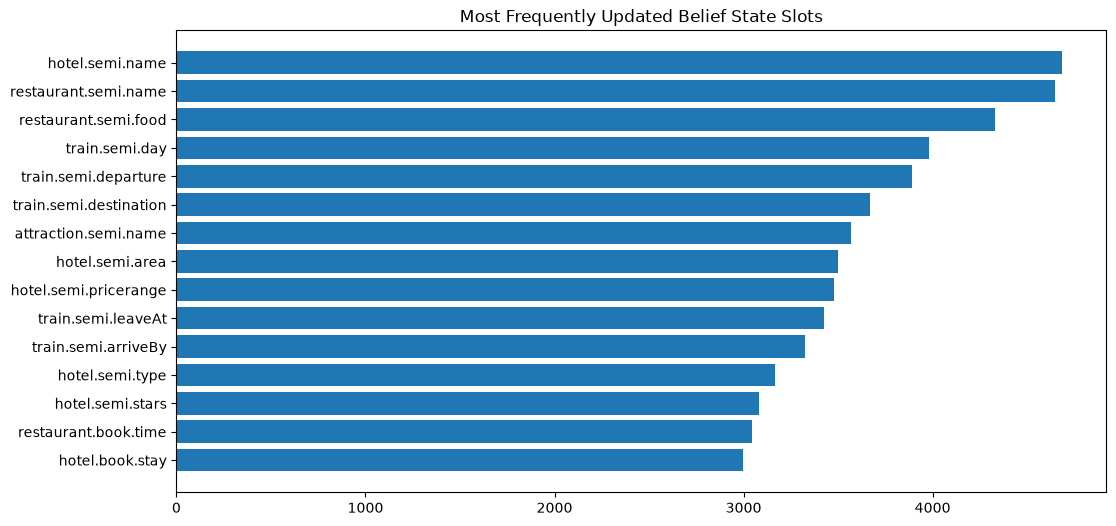

In [62]:
top_slots = slot_counter.most_common(15)

names = [x[0] for x in top_slots]
values = [x[1] for x in top_slots]

plt.figure(figsize=(12,6))

plt.barh(names, values)

plt.title("Most Frequently Updated Belief State Slots")

plt.gca().invert_yaxis()

plt.show()

Research Observations

## MultiWOZ Observations

- MultiWOZ contains approximately 10438 dialogues.
- Dialogues contain an average of _____ turns.
- Hotel and restaurant are the most frequently occurring domains.
- Many conversations span multiple domains, making the dataset suitable for studying context drift.
- The belief state evolves incrementally after user interactions and is stored within the metadata of system turns.
- Frequently updated slots include booking details (e.g., day, people, stay) and user preferences (e.g., parking, internet, price range).
- These structured belief state transitions provide an objective representation of conversational context, making MultiWOZ an ideal dataset for implementing the proposed Context Monitoring and Drift Detection Agents.

# PersonaChat Dataset

In [63]:
from pathlib import Path

persona_path = Path("../datasets/personachat")

for file in persona_path.rglob("*"):
    print(file)

../datasets/personachat/test_none_original.txt
../datasets/personachat/test_other_revised.txt
../datasets/personachat/train_self_revised.txt
../datasets/personachat/train_both_original.txt
../datasets/personachat/valid_none_original.txt
../datasets/personachat/valid_other_revised.txt
../datasets/personachat/train_both_revised.txt
../datasets/personachat/train_self_original.txt
../datasets/personachat/test_both_original.txt
../datasets/personachat/test_self_original.txt
../datasets/personachat/valid_self_original.txt
../datasets/personachat/train_none_original.txt
../datasets/personachat/valid_both_original.txt
../datasets/personachat/train_other_revised.txt
../datasets/personachat/test_other_original.txt
../datasets/personachat/valid_other_original.txt
../datasets/personachat/test_self_revised.txt
../datasets/personachat/test_both_revised.txt
../datasets/personachat/valid_self_revised.txt
../datasets/personachat/valid_both_revised.txt
../datasets/personachat/train_other_original.txt


In [64]:
from pathlib import Path

train_file = Path("../datasets/personachat/train_both_original.txt")

with open(train_file, "r", encoding="utf-8") as f:
    for _ in range(20):
        print(next(f).strip())

1 your persona: i like to remodel homes.
2 your persona: i like to go hunting.
3 your persona: i like to shoot a bow.
4 your persona: my favorite holiday is halloween.
5 partner's persona: i like canning and whittling.
6 partner's persona: to stay in shape , i chase cheetahs at the zoo.
7 partner's persona: in high school , i came in 6th in the 100 meter dash.
8 partner's persona: i eat exclusively meat.
9 hi , how are you doing ? i am getting ready to do some cheetah chasing to stay in shape .	you must be very fast . hunting is one of my favorite hobbies .		my mom was single with 3 boys , so we never left the projects .|i try to wear all black every day . it makes me feel comfortable .|well nursing stresses you out so i wish luck with sister|yeah just want to pick up nba nfl getting old|i really like celine dion . what about you ?|no . i live near farms .|i wish i had a daughter , i am a boy mom . they are beautiful boys though still lucky|yeah when i get bored i play gone with the wi

In [65]:
from pathlib import Path

train_file = Path("../datasets/personachat/train_both_original.txt")

In [66]:
conversation_count = 0

with open(train_file, encoding="utf-8") as f:

    for line in f:

        if line.startswith("1 your persona:"):
            conversation_count += 1

print("Total Conversations:", conversation_count)

Total Conversations: 8939


In [67]:
persona_lengths = []

current = 0

with open(train_file, encoding="utf-8") as f:

    for line in f:

        if "your persona:" in line:

            current += 1

        elif current:

            persona_lengths.append(current)
            current = 0

print("Average Persona Length:",
      sum(persona_lengths)/len(persona_lengths))

Average Persona Length: 4.5015102360443


In [68]:
conversation_lengths = []

current_turns = 0

with open(train_file, encoding="utf-8") as f:

    for line in f:

        number = int(line.split()[0])

        if number == 1 and current_turns:

            conversation_lengths.append(current_turns)
            current_turns = 1

        else:

            current_turns += 1

conversation_lengths.append(current_turns)

print("Average Turns:",
      sum(conversation_lengths)/len(conversation_lengths))

Average Turns: 16.342320170041393


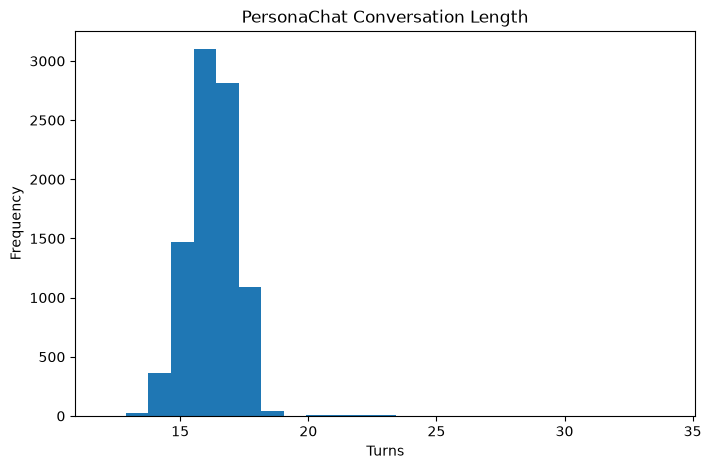

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(conversation_lengths, bins=25)

plt.title("PersonaChat Conversation Length")

plt.xlabel("Turns")

plt.ylabel("Frequency")

plt.show()